## Laboratorium 11

slajd 112 wyswietlic - ile razy algorytm sie pomylił i wybrał złego dostawcę

zadania ze slajdu 104

w 3 punkcie zmiana u dostawców (np jeden przestaje być najlepszym)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

1. Reproduce example from the lecture (electronic system production)

In [2]:
class Batch:
    quality = 0.5
    alpha = 1
    beta = 1

    def __init__(self, quality):
        self.quality = quality

    def sample_distribution(self):
        return np.random.beta(self.alpha, self.beta)

    def get_element(self):
        good = np.random.rand() < self.quality
        self.alpha = self.alpha + int(good)
        self.beta = self.beta + 1 - int(good)
        return good


class Factory:
    batches = []
    systems = 0
    good = 0

    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.systems = 0
        self.good = 0

    def get_element(self):
        samples = [batch.sample_distribution() for batch in self.batches]
        choice = np.argmax(samples)
        result = self.batches[choice].get_element()
        self.systems = self.systems + 1
        self.good = self.good + int(result)

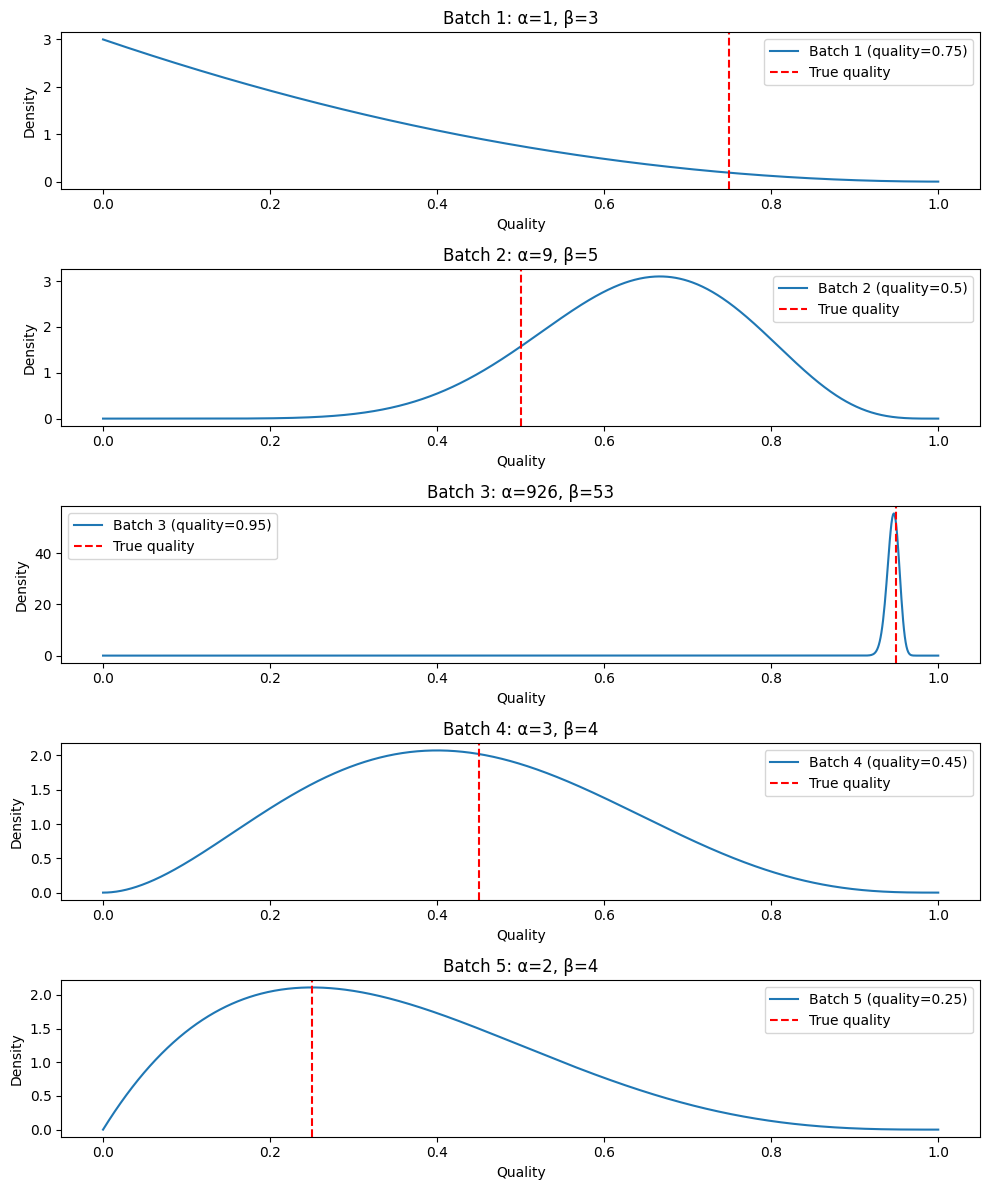

In [3]:
BATCHES_NUM = 5
qualities = [0.75, 0.5, 0.95, 0.45, 0.25]

STEPS = 1000

factory = Factory()
factory.set_batches(qualities)
res = {}

for step in range(STEPS):
    factory.get_element()
    res[step] = [(b.alpha, b.beta, b.quality) for b in factory.batches]

x = np.linspace(0,1,1000)
fig, axes = plt.subplots(BATCHES_NUM, 1, figsize=(10, 12))

for i in range(BATCHES_NUM):
    alpha_final, beta_final, quality = res[STEPS-1][i]
    y = beta.pdf(x, alpha_final, beta_final)
    axes[i].plot(x, y, label=f'Batch {i+1} (quality={quality})')
    axes[i].axvline(quality, color='r', linestyle='--', label='True quality')
    axes[i].set_title(f'Batch {i+1}: α={alpha_final}, β={beta_final}')
    axes[i].legend()
    axes[i].set_xlabel('Quality')
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

2. Implement last three strategies from slide 105 plus one of your own (other than the two 
remaining in the slide), compare results in a plot.

In [ ]:
class Batch:
    quality = 0.5
    alpha = 1
    beta = 1
    def __init__(self, quality):
        self.quality = quality
    
    def sample_distribution(self):
        return np.random.beta(self.alpha, self.beta)
    
    def get_element(self):
        good = np.random.rand() < self.quality
        self.alpha = self.alpha + int(good)
        self.beta = self.beta + 1 - int(good)
        return good
    
class Factory:
    batches = []
    systems = 0
    good = 0

    def reset(self):
        self.systems = 0          
        self.good = 0
    
    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.n_batches = len(qualities)
        self.systems = 0
        self.good = 0

    def step(self):
        choice = self.choose_next_method()

        result = self.batches[choice].get_element() # zwraca True dobry / False wadliwy
        self.systems = self.systems + 1
        self.good = self.good + int(result)
        return result
    
    def lemon_method(self, steps):
        results = []

        last_batch_idx = 0
        for step in range(steps):
            choice = last_batch_idx
            result = self.batches[choice].get_element()

            self.systems = self.systems + 1
            self.good = self.good + int(result)

            if result == False:
                last_batch_idx = last_batch_idx + 1 if last_batch_idx + 1 < self.n_batches else 0
            
            results.append(result)
            
        return results.count(True)
    
    def choose_best_method(self, steps):
        results = []
        for step in range(steps):
            samples = [b.sample_distribution() for b in self.batches]
            choice = np.argmax(samples)

            result = self.batches[choice].get_element()
            self.systems = self.systems + 1
            self.good = self.good + int(result)
            results.append(result)

        return results.count(True)
    
    def strat_rank_method(self, steps):
        results = []
        batch_success = np.zeros(self.n_batches)
        batch_used = np.zeros(self.n_batches)

        for step in range(steps):
            s = np.divide(batch_success, batch_used, out=np.zeros_like(batch_success), where=batch_used > 0)

            order = np.argsort(-s)
            schedule = []
            for i, idx in enumerate(order):
                schedule += [idx] * (self.n_batches - i)

            choice = schedule[step % len(schedule)]

            result = self.batches[choice].get_element()
            batch_success[choice] += int(result)
            batch_used[choice] += 1
            results.append(result)
        
        # return sum(batch_success) / sum(batch_used)
        return results.count(True)

In [ ]:
BATCHES_NUM = 5
qualities = [0.75, 0.5, 0.95, 0.45, 0.25]

STEPS = 1000
SIM_NUM = 100

Lemon method:

In [6]:
cumulative_good = []
for sim in range(SIM_NUM):
    scores = []
    factory = Factory()
    factory.set_batches(qualities)
    cumulative_good.append(factory.choose_next_method(STEPS))
    factory.reset()

print(sum(cumulative_good) / SIM_NUM)


828.42


In [7]:
cumulative_good = []
for sim in range(SIM_NUM):
    scores = []
    factory = Factory()
    factory.set_batches(qualities)
    cumulative_good.append(factory.choose_best_method(STEPS))
    factory.reset()

print(sum(cumulative_good) / SIM_NUM)


939.57


In [8]:
cumulative_good = []
for sim in range(SIM_NUM):
    scores = []
    factory = Factory()
    factory.set_batches(qualities)
    cumulative_good.append(factory.strat_rank_method(STEPS))
    factory.reset()

print(sum(cumulative_good) / SIM_NUM)


688.3
